# Notebook 2: Feature Engineering Author Names

Written By Kelly-Marie Yokuda for the BrainStation Capstone Project "Professor Power Index"

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import seaborn as sns
import os
from difflib import SequenceMatcher

# Project Introduction

To assist early career researchers in establishing their prestige, we demonstrate how machine learning can help early career researchers identify potential co-authors within their network whose added authorship could increase the likelihood of their research being published in highly-cited scientific journals. Specifically, we show that a classification model trained on a database of publications authored by prestigious researchers can successfully classify publications into tiers of highly-cited scientific journals using co-author metrics alone. 

# Notebook Introduction

## 2.1 Addressing Authorship Ambiguity

The objective of **Section 2.1** is to standardize the formatting of the author names across `papers_df` and `profile_df`.

First, we'll read the pickle files from Notebook 1 for `papers_df` and `profile_df`.

In [2]:
papers_df = pd.read_pickle(r'output\NB1_V2.1_papers_df.pkl')
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24657 entries, 0 to 24656
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           24657 non-null  int16  
 1   Authors         24657 non-null  object 
 2   Title           24657 non-null  object 
 3   Year            24657 non-null  int16  
 4   Source          24657 non-null  object 
 5   GSRank          24657 non-null  int16  
 6   Type            24657 non-null  object 
 7   ECC             24657 non-null  int16  
 8   CitesPerYear    24657 non-null  float16
 9   CitesPerAuthor  24657 non-null  int16  
 10  AuthorCount     24657 non-null  int8   
 11  profile_id      24657 non-null  int16  
dtypes: float16(1), int16(6), int8(1), object(4)
memory usage: 1.1+ MB


In [3]:
profile_df = pd.read_pickle(r'output/NB1_V2.1_profile_df.pkl')
profile_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      616 non-null    int16 
 1   Query   616 non-null    object
dtypes: int16(1), object(1)
memory usage: 6.1+ KB


### 2.1.1 Mapping Individual Values in `Authors` into Separate Columns

Currently, the author names in `papers_df` are stored in the `Authors` column as a single string.

In [5]:
papers_df['Authors']

0        D Shi, V Adinolfi, R Comin, M Yuan, E Alarousu...
1        K Lin, J Xing, LN Quan, FPG de Arquer, X Gong,...
2        SA McDonald, G Konstantatos, S Zhang, PW Cyr, ...
3        H Tan, A Jain, O Voznyy, X Lan, FP García de A...
4        G Konstantatos, I Howard, A Fischer, S Hooglan...
                               ...                        
24652                        Y Shin, S Cho, S Han, GY Jung
24653    C Liu, Y Yang, K Rakstys, A Mahata, M Franckev...
24654    S Driukas, D Rutkauskas, M Franckevičius, J Ch...
24655    M Faizan, KC Bhamu, G Murtaza, X He, N Kulhari...
24656    Z Zada, R Zada, AA Khan, M Saqib, MFU Rehman, ...
Name: Authors, Length: 24657, dtype: object

In [10]:
print('The value for the first row of Author column is type', type(papers_df.loc[0, 'Authors']))

The value for the first row of Author column is type <class 'str'>


Let's seperate each of the author names and map them into thier own column. Below is the author names expanded into their own data frame (first 5 rows).

In [11]:
# Stripping the white space from the ends of the strings
papers_df['Authors'] = papers_df['Authors'].str.strip()

# Splitting the strings into lists using the delimeter ','
papers_df['Authors'] = papers_df['Authors'].str.rsplit(',')

# Expanding the lists into their own data frame
auth_df = pd.DataFrame([np.asarray(i) for i in papers_df['Authors'].values])
auth_df.head(5)

,0,1,2,3,4,5,6,7,8,9,10,11
0,D Shi,V Adinolfi,R Comin,M Yuan,E Alarousu,A Buin,Y Chen,...,None,None,None,None
1,K Lin,J Xing,LN Quan,FPG de Arquer,X Gong,J Lu,L Xie,W Zhao,...,None,None,None
2,SA McDonald,G Konstantatos,S Zhang,PW Cyr,EJD Klem,L Levina,...,None,None,None,None,None
3,H Tan,A Jain,O Voznyy,X Lan,FP García de Arquer,JZ Fan,...,None,None,None,None,None
4,G Konstantatos,I Howard,A Fischer,S Hoogland,J Clifford,E Klem,...,None,None,None,None,None


Here, we see that each row has a different amount of authors. For this study, we'll only use the descriptive values for the first three authors.

In [12]:
auth_df = auth_df.iloc[:, :3]
auth_df.columns = ['first_auth', 'second_auth', 'third_auth']

Here is the first 5 rows of the new data frame.

In [13]:
auth_df.head(5)

,first_auth,second_auth,third_auth
0,D Shi,V Adinolfi,R Comin
1,K Lin,J Xing,LN Quan
2,SA McDonald,G Konstantatos,S Zhang
3,H Tan,A Jain,O Voznyy
4,G Konstantatos,I Howard,A Fischer


Let's append this data frame to `papers_df` and drop the `Authors` column.

In [14]:
papers_df = pd.concat([auth_df, papers_df.drop('Authors', axis = 1)], axis = 1)

Here is the new `papers_df`.

In [15]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24657 entries, 0 to 24656
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      24657 non-null  object 
 1   second_auth     24368 non-null  object 
 2   third_auth      23374 non-null  object 
 3   Cites           24657 non-null  int16  
 4   Title           24657 non-null  object 
 5   Year            24657 non-null  int16  
 6   Source          24657 non-null  object 
 7   GSRank          24657 non-null  int16  
 8   Type            24657 non-null  object 
 9   ECC             24657 non-null  int16  
 10  CitesPerYear    24657 non-null  float16
 11  CitesPerAuthor  24657 non-null  int16  
 12  AuthorCount     24657 non-null  int8   
 13  profile_id      24657 non-null  int16  
dtypes: float16(1), int16(6), int8(1), object(6)
memory usage: 1.5+ MB


After expanding the author names, it looks like there were some null values introduced in the new features. Let's look at their distribution.

Text(0.5, 0, 'Fraction of Null Values Per Column')

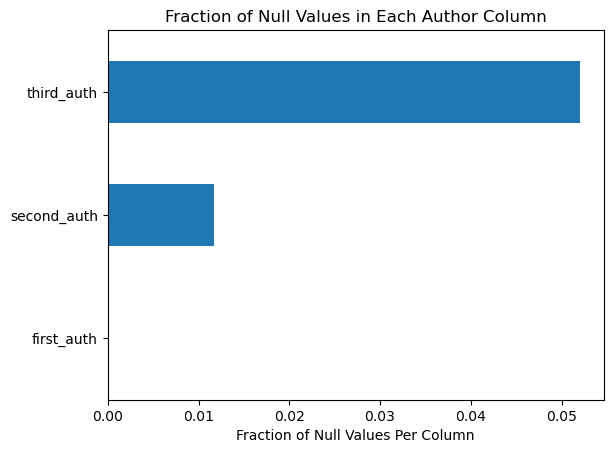

In [33]:
sum_ser = papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']].isna().sum()
cts_ser = papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']].isna().count()

(sum_ser/cts_ser).plot(kind = 'barh')
plt.title('Fraction of Null Values in Each Author Column')
plt.xlabel('Fraction of Null Values Per Column')

From this distribution, we see that about 5% of rows have null values for `third_auth` and a little over 1% have null values for `second_auth`. In contrast, none of the rows have null values for `first_author`, which is encouraging that the author expansion method worked adequately. Since all the rows with null values for `third_auth` likely have null values for `second_auth`, and these rows only represent about 5% of the data set, let's drop the rows where there are null values for `third_auth`.

In [36]:
papers_df.dropna(subset = 'third_auth').isna().sum()

first_auth        0
second_auth       0
third_auth        0
Cites             0
Title             0
Year              0
Source            0
GSRank            0
Type              0
ECC               0
CitesPerYear      0
CitesPerAuthor    0
AuthorCount       0
profile_id        0
dtype: int64

It looks like that removed all the null values. Let's offically drop the rows where there are null values for `third_auth` in `papers_df`.

In [37]:
papers_df = papers_df.dropna(subset = 'third_auth').reset_index(drop = True)

Here is the new `papers_df`

In [38]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23374 entries, 0 to 23373
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      23374 non-null  object 
 1   second_auth     23374 non-null  object 
 2   third_auth      23374 non-null  object 
 3   Cites           23374 non-null  int16  
 4   Title           23374 non-null  object 
 5   Year            23374 non-null  int16  
 6   Source          23374 non-null  object 
 7   GSRank          23374 non-null  int16  
 8   Type            23374 non-null  object 
 9   ECC             23374 non-null  int16  
 10  CitesPerYear    23374 non-null  float16
 11  CitesPerAuthor  23374 non-null  int16  
 12  AuthorCount     23374 non-null  int8   
 13  profile_id      23374 non-null  int16  
dtypes: float16(1), int16(6), int8(1), object(6)
memory usage: 1.4+ MB


### 2.1.2 Reformatting Author Names in `papers_df` and `profile_df`

To address authorship ambiguity in the data set, we must apply a standard string format for all the values in the author's column `papers_df` and the `Query` column of `profile_df`. We will use a similar formatting process done in **Section 1.5** using the following protocol:

1. Encode the string in ASCII
2. No name prefixes or suffixes (Ph.D., Dr, jr, etc.)
3. Remove any UTF-8 characters
4. All characters are lowercase

In [160]:
import re

def edit_names(name):
    
    '''
    
    Cleans up an author's name by removing non-UTF-8 characters, titles, and other
    extraneous information using regex.
    
    Parameters:
    ----------
    name: str 
        A string representing a name.

    Returns:
    -------
    str: The cleaned up name string, converted to lowercase and stripped of leading/trailing whitespace. 
    None: If the input is not a string, or if the cleaned up name string is empty, returns None.
    
    '''

        
    if isinstance(name, str):
        # remove any non-UTF-8 characters using encode method
        name = name.encode('ascii', 'ignore').decode('ascii')
        
        # remove any parenthess, hyphans and periodsusing regenx
        name = re.sub(r'[^a-zA-Z\s]', '', name).strip()

        # remove double spaces
        name = re.sub(r'  ', '', name).strip()

        # Use re to remove commas and anything after them
        name = re.sub(r'\,.*', '', name).strip()

        # Use re to remove title: Dr
        name = re.sub(r'^Dr\.?\s*', '', name).strip()

        # Use re to remove title: phd
        name = re.sub(r'^PhD\s*', '', name).strip()

        # Use re to remove phd
        name = re.sub(r'Ph\.?D\.?.*', '', name).strip()

        # Use re to remove title: Proff.
        name = re.sub(r'^PROFF\.?\s*', '', name).strip()

        # Remove the title: 'jr'
        name = re.sub(r'jr\.?s*', '', name).strip()

        # Rmove the title 'Junior'
        name = re.sub(r'junior', '', name).strip()

        # Remove 'equal contribution'
        name = re.sub(r'equal contribution', '', name).strip()

        # Remove 'ltslmw'
        name = re.sub(r'lts', '', name).strip()

        # Remove 'lmw'
        name = re.sub(r'lmw', '', name).strip()

        # Remove 'orcid'
        name = re.sub(r'ORCID:0000000160401920', '', name).strip()
        
        # remove '= equal first authors'
        name = re.sub(r' equal first authors', '', name).strip()
        
        if name != '':
            return name.lower().strip()
        else:
            return None
    else:
        return None

def edit_papers_names(row):
    
    '''
    Preps rows in `papers_df` for being passed into edit_names by looping over each column 
    in the given row.
    
    Parameters:
    ----------
    row: str
        A row from a Pandas DataFrame
    
    Returns:
    -------
    ret: list 
         A list containing the re-formatted author names.
    '''
    
    return [edit_names(i) for i in row]

def edit_profile_names(row):
    '''
    Preps rows in `profile_df` for being passed into edit_names for re-formatting by splitting the affiliation 
    from the author's name.
    
    Parameters:
    ----------
    row: pandas.Series
        A row from a Pandas DataFrame
    
    Returns:
    -------
    ret_val: str 
        The re-formatted name from the function
    
    '''
    # Splits affiliation from author's name
    split_col = [i.strip() for i in row['Query'].rsplit(' - ')]
    
    # author's name is the first element
    name = split_col[0]
    
    # Passing through edit_names
    ret_val = edit_names(name)
    return ret_val

First, let's format the author names in `profile_df`. In `profile_df`, the author names are stored under the column `Query`. Here is a sample of the first 5 rows of `Query` before formatting.

In [20]:
profile_df['Query'].head(5)

0               Edward Sargent - University of Toronto
1    Norbert Koch - Institut für Physik &IRIS Adler...
2    Dieter Neher - University of Potsdam, Institut...
3    Daniel Duprez - IC2MP, Université de Poitiers,...
4       Sergey Makarov - Professor, Head of Laboratory
Name: Query, dtype: object

Here we see that the name of the author and their affiliation are in one string. Therefore, before each row is formatted, the author's name needs to be seperated from the affliation. This will all be done together by applying the function `edit_profile_names()` to each row in the data frame. Let's reformat the names and store the results in a new column `profile_author`.

In [23]:
profile_df = profile_df.assign(profile_author = profile_df.apply(edit_profile_names, axis = 1))

Here are the first 5 rows of the reformatting author names in `profile_author`.

In [24]:
profile_df['profile_author'].head(5)

0    edward sargent
1      norbert koch
2      dieter neher
3     daniel duprez
4    sergey makarov
Name: profile_author, dtype: object

We see that method successfully reformatted the names in `profile_df`. Since we don't expect names in `profile_df` to overlap, we can check if the reformatting step maintained the number of unique author names.

In [27]:
result = profile_df['profile_author'].value_counts().sum() == profile_df['Query'].value_counts().sum()
print('Are the number of unqiue author names maintained?\t', result)

Are the number of unqiue author names maintained?	 True


Let's perform the reformatting process on `papers_df`. Unlike the process done on `profile_df`, we don't have to split anything from the strings before they're reformatted, the `edit_names` function just needs to be applied to every column in the rows. This will all be done using the function `edit_papers_names`. Let's reformat the names in `papers_df`, but wait on overwriting the original names.

In [40]:
test_df = papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']].apply(edit_papers_names)

Here are the first 5 rows of the reformatted names.

In [41]:
test_df.head(5)

,first_auth,second_auth,third_auth
0,d shi,v adinolfi,r comin
1,k lin,j xing,ln quan
2,sa mcdonald,g konstantatos,s zhang
3,h tan,a jain,o voznyy
4,g konstantatos,i howard,a fischer


From this output, the reformatting was successful. However, unlike the names in `profile_df`, we expect the number of unique author names to decrease as we standardize the formatting. So, let's see if the new formatting reduced the number of unique author names.

In [159]:
def get_unique_auth(df):
    
    '''
    Given a pandas DataFrame `df` containing columns named 'first_auth', 'second_auth', and 'third_auth', this function 
    concatenates the values of these columns into a single list, creates a pandas Series from this list, and then calculates 
    the number of unique values in the Series. The function then prints the number of unique author names found in the DataFrame, 
    and returns the count as an integer.

    Parameters:
    -----------
    df : pandas.DataFrame
        A DataFrame containing columns named 'first_auth', 'second_auth', and 'third_auth', which should contain string 
        values representing author names.
    
    Returns:
    --------
    ret: int
        The count of unique author names found in the DataFrame.
    
    '''
    
    author_list = np.concatenate(df.loc[:, ['first_auth', 'second_auth', 'third_auth']].values)
    auth_ser = pd.Series(author_list)
    
    unique_names = auth_ser.unique().shape[0]
    print(f"There are {unique_names} unique author names")
    return unique_names

In [48]:
print('Before Reformatting')
before = get_unique_auth(papers_df)
print('---')
print('After Reformatting')
after = get_unique_auth(test_df)
print('---')
print(f'That is {before-after} additional names grouped!')

Before Reformatting
There are 22127 unique author names
---
After Reformatting
There are 17593 unique author names
---
That is 4534 additional names grouped!


From this result, we see that applying the standard formatting grouped over 4,500 names, thereby sucessfully lowering the authorship ambiguity of the data set. Let's overrite the author names in `papers_df` with the reformatted names.

In [49]:
papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']] = test_df

Here is a sample of 5 rows of the author columns for the new `papers_df`:

In [51]:
papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']].sample(5)

,first_auth,second_auth,third_auth
2694,j caldern,j lvarez,j martinezpastor
8067,a krishna,d sabba,j yin
13910,ae enciso,g doni,r nifos
5116,o lupan,v postica,t pauport
12768,s kim,jh jung,ss lee


### 2.1.3 Grouping of Author Names Across `papers_df` and `profile_df`

The next step in reducing the authorship ambiguity in the data set is to find unique formats of names that belong to the same author that the previous reformatting method couldn't consolidate. For example, a search of the author names in `papers_df` shows that the author *Edward H Sargent* is cited in the following formats:

In [75]:
author_list = np.concatenate(papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']].values)
ser = pd.Series(author_list)
for i in ser[ser.str.contains('sargent') == True].unique():
    print(i)

eh sargent
e sargent
eth sargent


Therefore, we need to employ a method that will be able to idetnify and group the names that refer to the same author.

Before employing this method, let's combine the author name columns in `papers_df` and `profile_df` into one data frame named `join_df` to consolidate the names across both data sets.

In [76]:
join_df = pd.merge(left = papers_df, right = profile_df[['id', 'profile_author']], left_on = 'profile_id', right_on = 'id')

In [80]:
# only want to columns with the author names
join_df = join_df.loc[:, ['first_auth', 'second_auth', 'third_auth', 'profile_author']]

Here are 4 sampled rows from `join_df`:

In [99]:
join_df.loc[[19, 63, 481, 578],:]

,first_auth,second_auth,third_auth,profile_author
19,cr kagan,e lifshitz,eh sargent,edward sargent
63,j yang,e sargent,s kelley,edward sargent
481,eh sargent,gl tan,jm xu,edward sargent
578,eth sargent,g tan,jm xu,edward sargent


Using names from `join_df`, there are two methods we will employ to group the author names.

**Method 1**: Grouping By Rows

The algorithm will search row-wise for names that are at least 90% similar using the method `SequenceMatcher`. The name with the most amount of characters (highlighted in blue) will replace other matched names (highlighted in red). For example, since the values in `profile_author` are full names, this method will replace instances of the `profile_author` values found in the `papers_df` author columns.

Before replacement:

|	|first_auth|second_auth |third_auth|profile_author     |
|---|----------|------------|----------|-------------------| 
|19 |cr kagan  |e lifshitz  |<span style="color: red;"> eh sargent<span>|<span style="color: blue;">edward sargent<span>|
|63 |j yang    |<span style="color: red;">e sargent<span> |b oregan     |<span style="color: blue;">edward sargent<span>|
|481|<span style="color: red;">eh sargent<span>|gl tan	|jm xu	        |<span style="color: blue;">edward sargent<span>|
|578 |<span style="color: red;">eth sargent<span>|g tan	|jm xu          |<span style="color: blue;">edward sargent<span>|

After replacement:

|	|first_auth|second_auth |third_auth|profile_author     |
|---|----------|------------|----------|-------------------| 
|19 |cr kagan  |e lifshitz  |<span style="color: blue;">edward sargent<span>|<span style="color: blue;">edward sargent<span>|
|63 |j yang    |<span style="color: blue;">edward sargent<span>|b oregan     |<span style="color: blue;">edward sargent<span>|
|481|<span style="color: blue;">edward sargent<span>|gl tan	|jm xu	        |<span style="color: blue;">edward sargent<span>|
|578 |<span style="color: blue;">edward sargent<span>|g tan	|jm xu          |<span style="color: blue;">edward sargent<span>|

**Method 2**: Grouping by `profile_author`

The algorithum will search all the author values for data frames grouped by `profile_author` to find names that are at least 90% similar using the method `SequenceMatcher`. The name with the most amount of characters (highlighted in blue) will replace other matched names (highlighted in red). 

Before replacement:

|	|first_auth    |second_auth    |third_auth|profile_author     |
|---|--------------|---------------|----------|-------------------| 
|19 |cr kagan      |e lifshitz     |edward sargent|edward sargent|
|63 |j yang        |edward sargent |b oregan     |edward sargent|
|481|edward sargent|<span style="color: blue;">gl tan<span>	|jm xu	        |edward sargent|
|578|edward sargent|<span style="color: red;">g tan<span>	|jm xu          |edward sargent|

After replacement:

|	|first_auth    |second_auth    |third_auth|profile_author     |
|---|--------------|---------------|----------|-------------------| 
|19 |cr kagan      |e lifshitz     |edward sargent|edward sargent|
|63 |j yang        |edward sargent |b oregan     |edward sargent|
|481|edward sargent|<span style="color: blue;">gl tan<span>	|jm xu	        |edward sargent|
|578|edward sargent|<span style="color: blue;">gl tan<span>	|jm xu          |edward sargent|

To achieve these matches, we must determine a threshold value for `SequenceMatcher` to determine if the names refer to the same person. Using the Edward Sargent example, we find the name variations have the following match percentages:

In [112]:
name_samples = ['eh sargent', 'e sargent', 'eth sargent', 'edward sargent']

print('Name 1\tName 2\tMatch Percent')
print('-----------------------------')
for i in range(len(name_samples)):
    for j in range(i,len(name_samples)):
        a = name_samples[i]
        b = name_samples[j]
        if a!= b:
            r = SequenceMatcher(None, a, b).ratio()
            format_ = '{}\t{}\t{:0.2%}'.format(a,b,r)
            print(format_)

Name 1	Name 2	Match Percent
-----------------------------
eh sargent	e sargent	94.74%
eh sargent	eth sargent	95.24%
eh sargent	edward sargent	75.00%
e sargent	eth sargent	90.00%
e sargent	edward sargent	78.26%
eth sargent	edward sargent	72.00%


We find that the threshold must be at most 70% for all formatting variations to match. However, this threshold would also consider these names referring to the same person, even though they have different first initials and last names as shown below:

In [117]:
name_samples = ['s zhang', 'l zhang', 'j shang', 'j huang']

print('Name 1\tName 2\tMatch Percent')
print('-----------------------------')
for i in range(len(name_samples)):
    for j in range(i,len(name_samples)):
        a = name_samples[i]
        b = name_samples[j]
        if a!= b:
            r = SequenceMatcher(None, a, b).ratio()
            format_ = '{}\t{}\t{:0.2%}'.format(a,b,r)
            print(format_)

Name 1	Name 2	Match Percent
-----------------------------
s zhang	l zhang	85.71%
s zhang	j shang	71.43%
s zhang	j huang	71.43%
l zhang	j shang	71.43%
l zhang	j huang	71.43%
j shang	j huang	85.71%


One method to prevent strings with different first initials and last names is to check if the first letter of the last name and the first inital are the same. However, this would mean formatting variations where a last name is split into two seperate words will not be matched with the variation where it is not.

In [ ]:
 't he': 'tc he',
  't wu': 'tz wu',
  'ty wu': 'tz wu',

Make a `join_df`

In [ ]:
join_df = pd.merge(left = papers_df, right = profile_df[['id', 'profile_author']], left_on = 'profile_id', right_on = 'id')

In [ ]:
join_df.head()

In [ ]:
result = papers_df.shape[0] == join_df.shape[0]
print('Are the number of rows maintained?\t', result)

In [162]:
def custom_tokenizer(text):
    """
    Tokenizes the input text by splitting it into words and returning the last two characters of the last word
    in lower case.

    Parameters:
    ---------
    text: str 
        The input text to be tokenized.

    Returns:
    -------
    tokens: str
        The last two characters of the last word in lower case.
    """
    tokens = text.split()
    tokens = tokens[-1][-2:].lower()
    return tokens


def all_same(itemlist):
    """
    Determines if all elements in the input list are the same.

    Parameters:
    ---------
    itemlist: list
        A list of items to check for equality.

    Returns:
    -------
    ret: bool
        True if all elements in the input list are the same, False otherwise.
    """
    return all(x == itemlist[0] for x in itemlist)



def get_token_tag(text):
    
    '''
    Determines if the input text or list of texts should be tagged based on certain criteria.
    Crteria is layed out to prevent name pairs that would otherwise be grouped using SequenceMatcher from
    being considered at all.

    Parameters:
    ---------
    text: str or list
        A string or list of strings to be checked for tagging.

    Returns:
    ret: bool
        True if the input text or list of texts should be tagged, False otherwise.
   '''
    
    pass_letters =  ['x', 'y', 'z']
    pass_lastname = ['ee', 'ng', 'im', 'iu', 'an', 'on', 'ao', 'wu', 'hu', 'we', 'ei']
    
    if isinstance(text, str):
        
        token = custom_tokenizer(text)
        if token not in pass_lastname and\
            text[0] not in pass_letters:
            return True
        else:
            return False
    
    elif isinstance(text, list):
        
        a, b = text

        token_a = custom_tokenizer(a)
        token_b = custom_tokenizer(b)
        
        if a != b and a[0] == b[0] and\
            a[0] not in pass_letters and\
            b[0] not in pass_letters and\
            token_a not in pass_lastname and\
            token_b not in pass_lastname:
            
            return True

        else:
            return False
        
def match_names(row, v = 'v1', col = None, token_state = 'on', input_ratio = 0.90):
    
    """
    For each title in the data set, checks if there is more than one citation. If there is, checks
    if the names are formatted in the same way using SequnceMatcher (ratio testing) or by checking if names
    have the same initials. 
    
    If the names are not the same, returns the variation of the name that is the longest.

    Parameters:
    ---------
    row: pandas.Series
        The input row to be processed.
    v: str (default = 'v1') 
        The version of the function to use.
    col: str or None (default = None)
        The name of the column to group the rows by.
    token_state: str (default = 'on')
        The state of the tokenization function. If 'on', then ratio testing is only allowed if the name pairs
        pass the checks done by get_token_tag().
    input_ratio: float (default = 0.90)
        The minimum similarity ratio for names.

    Returns:
        dict or bool: A dictionary of names to be replaced, or False if no replacements are necessary.

    """
    if v == 'v1':
        # for grouping row-wise
        og_vals = row
    elif v == 'v2':
        # for grouping by profile_author
        og_vals = row[col].values
    
    # Initiates a list of unique names
    new_vals = np.unique([i for i in og_vals if isinstance(i, str)])
    
    last_names = [i.rsplit(' ')[-1] for i in new_vals] # make a list of the last names
    first_initial = [i.rsplit(' ')[0][0] for i in new_vals] # make a list of the first initial
    last_initial = [i.rsplit(' ')[-1][0] for i in new_vals] # make a list of the last initial
    
    if len(new_vals) > 1:
        
        replace_dic = {}
        
        # if all the names are not already the same
        if all_same(new_vals) == False:
            
            for i in range(0, len(new_vals)):
                    
                for j in range(i+1, len(new_vals)):
                        
                    a = new_vals[i]
                    b = new_vals[j]
                    
                    first_a, last_a, last_initial_a = first_initial[i], last_names[i], last_initial[i]
                    first_b, last_b, last_initial_b = first_initial[j], last_names[j], last_initial[j]
                    
                    if token_state == 'on':
                        
                        # use token_tag function to determine if the value passes
                        token_tag = get_token_tag([a,b])
                        
                        # allow token ratio testing
                        ratio_tag = True
                        
                    elif token_state == 'off':
                        
                        # If both names share the same last initial and first inital
                        if last_initial_a == last_initial_b and\
                            first_a == first_b:
                            token_tag = True
                        else:
                            token_tag = False
                        
                        # Turn off ratio testing
                        ratio_tag = False
                        
                    if token_tag == True:
                        
                        # If both names share the same last name and first inital
                        if last_a == last_b and first_a == first_b:
                            
                            name = [a,b]
                            name.sort(reverse = False, key = len)
                            replace_dic.update({name[0] : name[1]})
                    
                        else:
                            
                            if ratio_tag == True:
                            
                                r = SequenceMatcher(None, a, b).ratio()

                                if r > input_ratio: # if the names are at least x% similar

                                    name = [a,b]
                                    name.sort(reverse = False, key = len)
                                    replace_dic.update({name[0] : name[1]})
                    else:
                        pass
                        
        if len(replace_dic) != 0: #if replace_dic is not empty
            return replace_dic
        else:
            return False
    else:
        return False

In [163]:
def row_wise(df):
    
    """
    Compare names row-wise in a DataFrame and generate a replacement dictionary for similar names.

    Parameters:
    ----------
    df: pandas.DataFrame
        A DataFrame containing the columns 'first_auth', 'second_auth', 'third_auth', and 'profile_author'.

    Returns:
    -------
    tuple:
        A tuple containing:
        - A dictionary containing the names to be replaced and their replacements.
        - A string indicating that the comparison was done row-wise.
        - A string indicating the color to be used for plotting.

    """
    
    print('-- Comparing Names Row Wise --')
    
    ## Initiate the Replacement Dictionary 
    replace_dic = {}

    # Loop over each author column
    name_arr = np.asarray(df.loc[:, ['first_auth', 'second_auth', 'third_auth', 'profile_author']])

    for i in tqdm(range(name_arr.shape[0])):
        return_vals = match_names(name_arr[i, :], v = 'v1', token_state = 'off', input_ratio = 0.80)
        if return_vals:
            replace_dic.update(return_vals)
    
    return tuple(replace_dic, 'Row Wise', '#0072b2')

def groupby_profileAuthor(df):
    
    """
    Compare names by `profile_author` in a DataFrame and generate a replacement dictionary for similar names.

    Parameters:
    ----------
    df: pandas.DataFrame
        A DataFrame containing the columns 'first_auth', 'second_auth', 'third_auth', and 'profile_author'.

    Returns:
    -------
    tuple:
        A tuple containing:
        - A dictionary containing the names to be replaced and their replacements.
        - A string indicating that the comparison was done row-wise.
        - A string indicating the color to be used for plotting.

    """
    
    print('-- Comparing the names by profile_author --')
    
    # 1. Initiate the Replacement Dictionary 
    replace_dic = {}
    
    for i in tqdm(['first_auth', 'second_auth', 'third_auth']):
        return_vals = df.groupby('profile_author').apply(match_names, v = 'v2', col = i, token_state = 'on', input_ratio = 0.95).values
        for k in return_vals[return_vals != False]:
            replace_dic.update(k) 
            
    return tuple(replace_dic, 'profile Wise', '#d55e00')

In [152]:
new_join_df = join_df.copy()
j = 0

auth_cols = ['first_auth', 'second_auth', 'third_auth', 'profile_author']
auth_subcols = ['first_auth', 'second_auth', 'third_auth']

plt_dic = {'num_auth': [], 'labels': [], 'colors': [], 'iteration': [], 'change_first':[], 'change_second': [], 'change_third': [], 'change_profile': []}

num = get_unique_auth(join_df);
plt_dic['num_auth'].append(num)
plt_dic['labels'].append('Start')
plt_dic['colors'].append('#009e73')
plt_dic['iteration'].append(j)

for key in list(plt_dic.keys())[4:]:
    plt_dic[key].append(0)
    
while j < 5:
    
    print('\n')
    print(f'--- Performing Cycle {j+1} ---')
    print('\n')
    
    for func in [row_wise, groupby_profileAuthor]:
        
        replace_dic, label, color = func(join_df)
        
        compare_join_df = join_df.copy()
        
        join_df.loc[:, auth_subcols] = join_df.replace(replace_dic).loc[:, auth_subcols]
        num = get_unique_auth(join_df);
        plt_dic['num_auth'].append(num)
        plt_dic['labels'].append(label)
        plt_dic['colors'].append(color)
        plt_dic['iteration'].append(j)
        
        
        # Calculting the change in author names by column
        check_df = compare_join_df.loc[:, auth_cols] == join_df.loc[:, auth_cols]
        changed_ser = check_df.count() - check_df.sum()
        ch_first, ch_second, ch_third, ch_profile = changed_ser
        plt_dic['change_first'].append(ch_first)
        plt_dic['change_second'].append(ch_second)
        plt_dic['change_third'].append(ch_third)
        plt_dic['change_profile'].append(ch_profile)
        
        print('\n')
    
    j = j + 1

There are 17593 unique author names


--- Performing Cycle 1 ---


-- Comparing Names Row Wise --


  0%|          | 0/23374 [00:00<?, ?it/s]

There are 17454 unique author names


-- Comparing the names by profile_author --


  0%|          | 0/3 [00:00<?, ?it/s]

There are 17006 unique author names




--- Performing Cycle 2 ---


-- Comparing Names Row Wise --


...

There are 16969 unique author names




--- Performing Cycle 5 ---


-- Comparing Names Row Wise --


  0%|          | 0/23374 [00:00<?, ?it/s]

There are 16969 unique author names


-- Comparing the names by profile_author --


  0%|          | 0/3 [00:00<?, ?it/s]

There are 16969 unique author names




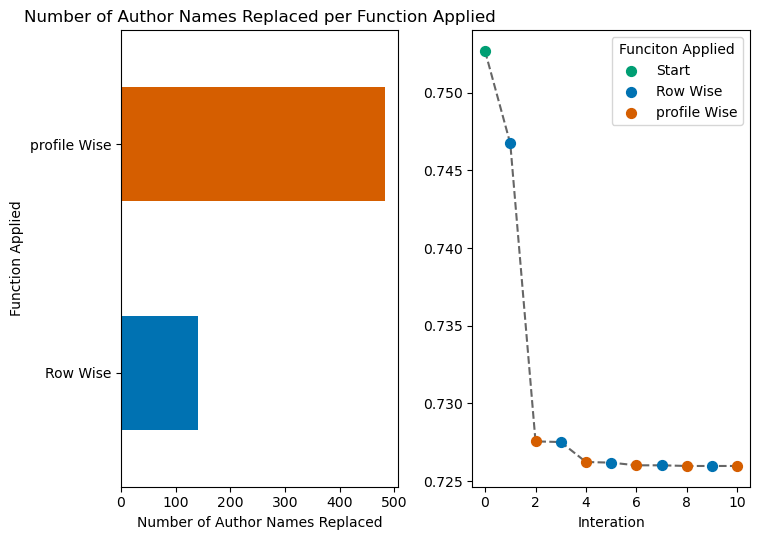

In [167]:
group_auth_df = pd.DataFrame(plt_dic)
group_auth_df = group_auth_df[group_auth_df['labels'] != 'Start']

fig, axes = plt.subplots(1, 2, figsize = (7.7, 5.5))

ax = axes[0]
colors = group_auth_df.groupby('labels')['colors'].apply(list).str[0].values.tolist()
bar_plot = group_auth_df.groupby('labels')['repl_auth'].sum().plot(kind = 'barh', color = colors, ax = ax)

bar_plot.set_title('Number of Author Names Replaced per Function Applied')
bar_plot.set_xlabel('Number of Author Names Replaced')
bar_plot.set_ylabel('Function Applied')


ax = axes[1]
colors = plt_dic['colors']
num_authors = plt_dic['num_auth']
labels = plt_dic['labels']

# The average number of unique authors per citation
uni_auth_per_cit = np.divide(num_authors, join_df.shape[0])

for i in range(len(num_authors)):
    ax.scatter(i, uni_auth_per_cit[i], label = labels[i], color = colors[i], marker = 'o', s = 50)

ax.plot(uni_auth_per_cit, color = 'black', ls = 'dashed', zorder = 0, alpha = 0.6)
ax.set_xlabel('Interation')

container, label = ax.get_legend_handles_labels()
ax.legend(container[:3], label[:3], title = 'Funciton Applied', )


fig.tight_layout()

---

First, let's remove all redundent publications.

In [168]:
papers_df['Title'].value_counts().count()

17719

In [169]:
papers_df['Title'] = papers_df['Title'].str.lower()

In [170]:
for i in papers_df.index:
    title = papers_df.loc[i, 'Title']
    if np.char.find(title, 'supporting information') != -1 \
        or np.char.find(title, 'reply to the comment') != -1 \
        or np.char.find(title, '{sub') != -1\
        or np.char.find(title, 'correction') != -1\
        or np.char.find(title, 'erratum') != -1:
        papers_df = papers_df.drop(i)

In [172]:
papers_df['Title'].value_counts().count()

17478

In [173]:
papers_df['Title'] = papers_df['Title'].str.replace(r'[^a-zA-Z\s]', '', regex = True)

In [174]:
papers_df['Title'].value_counts().count()

17449

In [176]:
get_unique_auth(papers_df)

There are 17574 unique author names


17574